# Stage 5: NSDE 神经随机微分方程期权定价

**核心创新**：将 Heston 模型的漂移和扩散项替换为神经网络，并整合情绪因子 z，实现动力学层面的情绪建模。

**标的资产价格过程**：
```
dS_t = μ_S(S_t, v_t, r, t, z) dt + σ_S(S_t, v_t, r, t, z) dW_t^S
```

**波动率过程**：
```
dv_t = μ_v(S_t, v_t, r, t, z) dt + σ_v(S_t, v_t, r, t, z) dW_t^v
```

**核心科学问题**：情绪因子 z 进入后，扩散项 σ_S, σ_v 能否捕捉散户恐慌驱动的波动率跳跃？

| 输入 | 输出 |
|------|------|
| `full_option_trading_data.csv`、`rr_surface_vae_train_only.pt`（stage_1） | Heston vs NSDE 配置1 vs 配置2 的 MAE/RMSE/MAPE 对比；诊断与建议 |

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from OptionPricingModel import (
    OptionPricingModel,
    extract_expiry_yymm,
    compute_metrics,
    set_seed,
    SEED,
)
from NeuralSDEPricer import NeuralSDEPricer
from RiskReversalSurfaceVAE import RiskReversalSurfaceVAE

set_seed()
plt.rcParams['font.family'] = ["Arial Unicode MS"]

## 1. 数据加载与清洗

In [5]:
# 加载数据，划分训练集(2401-2411)与测试集(2412)
df = pd.read_csv("full_option_trading_data.csv")
df["expiry_yymm"] = df["order_book_id"].apply(extract_expiry_yymm)
train_yymm = [f"24{i:02d}" for i in range(1, 12)]
df_train = df[df["expiry_yymm"].isin(train_yymm)].copy()
df_test = df[df["expiry_yymm"] == "2412"].copy()

def clean_option_data(d):
    d = d.dropna(subset=["underlying_close", "strike_price", "time_to_expire", 
                          "risk_free_rate", "close", "hv_20d", "call_put", "iv"])
    d = d[d["time_to_expire"] > 5/365]  # 剔除到期时间小于5天的"末日轮"
    d = d[d["close"] >= 0.2]  # 期权最低结算价 0.2
    d = d[d["hv_20d"] > 1e-6]
    d = d[d["iv"] > 1e-8]  # 排除 iv 缺失或异常小值
    return d

df_train = clean_option_data(df_train)
df_test = clean_option_data(df_test)
print(f"训练集: {len(df_train)}, 测试集: {len(df_test)}")

训练集: 42349, 测试集: 8701


## 2. 加载情绪因子

从 stage_1 的 VAE 模型中提取情绪因子

In [6]:
# 加载 VAE 模型（训练集专用）
import os
vae = RiskReversalSurfaceVAE(latent_dim=2, beta=0.01)
data_list_train, dates_train = vae.prepare_dataset(full_df=df_train)

vae_path = "rr_surface_vae_train_only.pt"
if os.path.exists(vae_path):
    vae.load_model(vae_path)
    print("已加载 VAE 模型（训练集专用）")
else:
    print("警告：未找到 VAE 模型，请先运行 stage_1")
    raise FileNotFoundError(f"未找到 {vae_path}")

# 提取训练集的情绪因子
sentiment_train = {}
for date, data in zip(dates_train, data_list_train):
    # vae.encode() 已经返回 numpy 数组，不需要 .detach().cpu().numpy()
    z_mean = vae.encode(data)
    sentiment_train[str(date)] = z_mean

print(f"训练集日期数量: {len(sentiment_train)}")

# 提取测试集的情绪因子（使用前一交易日）
data_list_test, dates_test = vae.prepare_dataset(full_df=df_test)
sentiment_test = {}
for date, data in zip(dates_test, data_list_test):
    # vae.encode() 已经返回 numpy 数组
    z_mean = vae.encode(data)
    sentiment_test[str(date)] = z_mean

print(f"测试集日期数量: {len(sentiment_test)}")

已加载 VAE 模型（训练集专用）
训练集日期数量: 398
测试集日期数量: 240


## 3. 训练 NSDE 模型

本阶段测试两组配置（对应 demo_loss_v0_tuning 的最优配置）：

### 配置1：baseline_mse_hv（原始基线）
- 损失函数：MSE
- v0来源：hv_20d
- 网络结构：[32, 32]
- 蒙特卡洛路径数：2000
- 时间步数：30
- residual_scale：0.3
- 训练轮数：20
- batch_size：64
- 学习率：5e-3
- 训练样本数：500
- 测试样本数：2000
- rho：-0.082（校准值）

### 配置2：baseline_mse_hv_0.2rs_-0.07rho（优化配置）
- 损失函数：MSE
- v0来源：hv_20d
- 网络结构：[32, 32]
- 蒙特卡洛路径数：2000
- 时间步数：30
- residual_scale：0.2（降低）
- 训练轮数：20
- batch_size：64
- 学习率：5e-3
- 训练样本数：2000（增大）
- 测试样本数：2000
- rho：-0.07（调整）

In [7]:
# 配置1：baseline_mse_hv（原始基线）
print("=" * 60)
print("配置1：baseline_mse_hv（原始基线）")
print("=" * 60)

nsde1 = NeuralSDEPricer(
    latent_dim=2,
    hidden_dims=[32, 32],
    n_paths=2000,
    n_steps=30,
    rho=-0.082,  # 使用校准值
    residual_scale=0.3,
    random_state=SEED
)

df_train_small1 = df_train.sample(n=min(2000, len(df_train)), random_state=SEED)

nsde1.fit(
    df_train_small1,
    sentiment_train,
    epochs=20,
    batch_size=64,
    lr=5e-3,
    n_paths_train=500,
    verbose=True
)

# 配置2：baseline_mse_hv_0.2rs_-0.07rho（优化配置）
print("\n" + "=" * 60)
print("配置2：baseline_mse_hv_0.2rs_-0.07rho（优化配置）")
print("=" * 60)

nsde2 = NeuralSDEPricer(
    latent_dim=2,
    hidden_dims=[32, 32],
    n_paths=2000,
    n_steps=30,
    rho=-0.07,  # 调整后的rho
    residual_scale=0.2,  # 降低残差缩放
    random_state=SEED
)

df_train_small2 = df_train.sample(n=min(2000, len(df_train)), random_state=SEED)

nsde2.fit(
    df_train_small2,
    sentiment_train,
    epochs=20,
    batch_size=64,
    lr=5e-3,
    n_paths_train=500,
    verbose=True
)

配置1：baseline_mse_hv（原始基线）
未提供 Heston 基准参数，开始校准...
校准完成: κ=3.387, θ=0.037, σ=1.000, ρ=-0.074, v0=0.019
训练样本数: 2000


Epoch 1/20: 100%|██████████| 32/32 [00:52<00:00,  1.64s/it, loss=3172.7568, mae=36.9402, grad=1.67e+03]


  Epoch 1/20, Loss: 3390.340680, MAE: 40.5019
  Grad: μ_S=0.00e+00, σ_S=1.22e+04, μ_v=1.07e+03, σ_v=9.68e+02


Epoch 2/20: 100%|██████████| 32/32 [00:52<00:00,  1.63s/it, loss=925.0469, mae=18.3977, grad=1.37e+03] 


  Epoch 2/20, Loss: 1208.819426, MAE: 22.8079
  Grad: μ_S=0.00e+00, σ_S=9.35e+03, μ_v=2.15e+01, σ_v=5.59e+02


...

  Epoch 18/20, Loss: 856.620666, MAE: 18.3895
  Grad: μ_S=0.00e+00, σ_S=2.30e+03, μ_v=3.94e+02, σ_v=6.96e+01


Epoch 19/20: 100%|██████████| 32/32 [00:52<00:00,  1.64s/it, loss=1443.8635, mae=25.6581, grad=5.24e+01]


  Epoch 19/20, Loss: 844.794518, MAE: 18.2271
  Grad: μ_S=0.00e+00, σ_S=2.64e+03, μ_v=4.03e+02, σ_v=6.97e+01


Epoch 20/20: 100%|██████████| 32/32 [00:52<00:00,  1.64s/it, loss=866.5084, mae=19.6508, grad=4.88e+01] 

  Epoch 20/20, Loss: 832.119520, MAE: 17.9892
  Grad: μ_S=0.00e+00, σ_S=2.16e+03, μ_v=3.77e+02, σ_v=7.84e+01


## 4. 两组配置的对比评估

分别评估两组配置的定价精度，并与 Heston 基准对比。

In [8]:
# 测试集样本
df_test_sample = df_test.sample(n=min(2000, len(df_test)), random_state=SEED)
y_test = df_test_sample['close'].values

# ===== 配置1评估 =====
print("=" * 60)
print("评估配置1：baseline_mse_hv")
print("=" * 60)

pred_nsde1_test, std_errors1 = nsde1.predict_batch(
    df_test_sample,
    sentiment_test,
    n_paths_test=2000,
    verbose=True
)

metrics_nsde1 = compute_metrics(y_test, pred_nsde1_test)

print("\n=== 配置1 测试集表现 ===")
print(f"MAE:  {metrics_nsde1['MAE']:.4f}")
print(f"RMSE: {metrics_nsde1['RMSE']:.4f}")
print(f"MAPE: {metrics_nsde1['MAPE']:.2f}%")
print(f"平均标准误差: {np.mean(std_errors1):.4f}")

# ===== 配置2评估 =====
print("\n" + "=" * 60)
print("评估配置2：baseline_mse_hv_0.2rs_-0.07rho")
print("=" * 60)

pred_nsde2_test, std_errors2 = nsde2.predict_batch(
    df_test_sample,
    sentiment_test,
    n_paths_test=2000,
    verbose=True
)

metrics_nsde2 = compute_metrics(y_test, pred_nsde2_test)

print("\n=== 配置2 测试集表现 ===")
print(f"MAE:  {metrics_nsde2['MAE']:.4f}")
print(f"RMSE: {metrics_nsde2['RMSE']:.4f}")
print(f"MAPE: {metrics_nsde2['MAPE']:.2f}%")
print(f"平均标准误差: {np.mean(std_errors2):.4f}")

# ===== 两组配置对比 =====
print("\n" + "=" * 60)
print("两组配置对比")
print("=" * 60)
comparison_df = pd.DataFrame({
    '配置1 (rs=0.3, n=500, rho=-0.082)': [
        metrics_nsde1['MAE'],
        metrics_nsde1['RMSE'],
        metrics_nsde1['MAPE']
    ],
    '配置2 (rs=0.2, n=2000, rho=-0.07)': [
        metrics_nsde2['MAE'],
        metrics_nsde2['RMSE'],
        metrics_nsde2['MAPE']
    ]
}, index=['MAE', 'RMSE', 'MAPE(%)'])
print(comparison_df)


评估配置1：baseline_mse_hv


预测中: 100%|██████████| 2000/2000 [02:28<00:00, 13.47it/s]



=== 配置1 测试集表现 ===
MAE:  68.1086
RMSE: 89.8846
MAPE: 94.90%
平均标准误差: 7.9738

评估配置2：baseline_mse_hv_0.2rs_-0.07rho


预测中: 100%|██████████| 2000/2000 [02:28<00:00, 13.46it/s]


=== 配置2 测试集表现 ===
MAE:  44.3837
RMSE: 59.0418
MAPE: 73.65%
平均标准误差: 6.9505

两组配置对比
         配置1 (rs=0.3, n=500, rho=-0.082)  配置2 (rs=0.2, n=2000, rho=-0.07)
MAE                            68.108599                        44.383747
RMSE                           89.884555                        59.041797
MAPE(%)                        94.899673                        73.654677


## 5. 【诊断】验证 Heston 基准定价精度

**关键问题**：如果训练 loss 很高，首先要确认纯 Heston 模型能达到什么精度。
理论上，NSDE = Heston + 神经网络残差，不应该比 Heston 本身差。

In [9]:
# 评估纯 Heston 模型作为基准
from OptionPricingModel import OptionPricingModel, HestonParams

print("=" * 60)
print("【Heston 基准】评估纯 Heston 模型在测试集上的定价精度")
print("=" * 60)

heston_baseline = OptionPricingModel()

# 使用配置1的校准参数
heston_params_1 = nsde1.heston_params
print(f"\n配置1的 Heston 参数:")
print(f"  κ={heston_params_1.kappa:.3f}")
print(f"  θ={heston_params_1.theta:.3f}")
print(f"  σ={heston_params_1.sigma:.3f}")
print(f"  ρ={heston_params_1.rho:.3f}")
print(f"  v0={heston_params_1.v0:.3f}")

# 使用配置2的校准参数
heston_params_2 = nsde2.heston_params
print(f"\n配置2的 Heston 参数:")
print(f"  κ={heston_params_2.kappa:.3f}")
print(f"  θ={heston_params_2.theta:.3f}")
print(f"  σ={heston_params_2.sigma:.3f}")
print(f"  ρ={heston_params_2.rho:.3f}")
print(f"  v0={heston_params_2.v0:.3f}")

# 用 Heston 模型预测（配置1参数）
print("\n使用配置1的 Heston 参数定价测试集...")
heston_pred_1 = []
for _, row in df_test_sample.iterrows():
    price = heston_baseline.price_heston(
        S=row['underlying_close'],
        K=row['strike_price'],
        r=row['risk_free_rate'],
        T=row['time_to_expire'],
        option_type='call' if row['call_put'] == 0 else 'put',
        params=heston_params_1,
    )
    heston_pred_1.append(price)

heston_pred_1 = np.array(heston_pred_1)
heston_metrics_1 = compute_metrics(y_test, heston_pred_1)

print("\n=== 纯 Heston 模型表现（配置1参数） ===")
print(f"MAE:  {heston_metrics_1['MAE']:.4f}")
print(f"RMSE: {heston_metrics_1['RMSE']:.4f}")
print(f"MAPE: {heston_metrics_1['MAPE']:.2f}%")

# 用 Heston 模型预测（配置2参数）
print("\n使用配置2的 Heston 参数定价测试集...")
heston_pred_2 = []
for _, row in df_test_sample.iterrows():
    price = heston_baseline.price_heston(
        S=row['underlying_close'],
        K=row['strike_price'],
        r=row['risk_free_rate'],
        T=row['time_to_expire'],
        option_type='call' if row['call_put'] == 0 else 'put',
        params=heston_params_2,
    )
    heston_pred_2.append(price)

heston_pred_2 = np.array(heston_pred_2)
heston_metrics_2 = compute_metrics(y_test, heston_pred_2)

print("\n=== 纯 Heston 模型表现（配置2参数） ===")
print(f"MAE:  {heston_metrics_2['MAE']:.4f}")
print(f"RMSE: {heston_metrics_2['RMSE']:.4f}")
print(f"MAPE: {heston_metrics_2['MAPE']:.2f}%")

# NSDE vs Heston 对比
print("\n" + "=" * 60)
print("NSDE vs Heston 对比")
print("=" * 60)

print("\n配置1：")
ratio_1 = metrics_nsde1['MAE'] / heston_metrics_1['MAE']
print(f"  NSDE MAE:   {metrics_nsde1['MAE']:.4f}")
print(f"  Heston MAE: {heston_metrics_1['MAE']:.4f}")
print(f"  比值: {ratio_1:.3f} (< 1 表示 NSDE 更好)")

print("\n配置2：")
ratio_2 = metrics_nsde2['MAE'] / heston_metrics_2['MAE']
print(f"  NSDE MAE:   {metrics_nsde2['MAE']:.4f}")
print(f"  Heston MAE: {heston_metrics_2['MAE']:.4f}")
print(f"  比值: {ratio_2:.3f} (< 1 表示 NSDE 更好)")

print("\n【结论】")
if ratio_1 < 1.0 and ratio_2 < 1.0:
    print("✓ 两组配置的 NSDE 均优于纯 Heston 模型，神经网络残差有效改善了定价精度")
elif ratio_1 < 1.0 or ratio_2 < 1.0:
    print("⚠️ 只有部分配置的 NSDE 优于 Heston，需进一步优化超参数")
else:
    print("❌ NSDE 未能超越 Heston 基准，可能存在以下问题：")
    print("   - residual_scale 过小，神经网络残差被压制")
    print("   - 训练样本不足")
    print("   - 学习率或训练轮数不够")

【Heston 基准】评估纯 Heston 模型在测试集上的定价精度

配置1的 Heston 参数:
  κ=3.387
  θ=0.037
  σ=1.000
  ρ=-0.074
  v0=0.019

配置2的 Heston 参数:
  κ=3.387
  θ=0.037
  σ=1.000
  ρ=-0.074
  v0=0.019

使用配置1的 Heston 参数定价测试集...

=== 纯 Heston 模型表现（配置1参数） ===
MAE:  34.6721
RMSE: 50.0850
MAPE: 30.46%

使用配置2的 Heston 参数定价测试集...

=== 纯 Heston 模型表现（配置2参数） ===
MAE:  34.6721
RMSE: 50.0850
MAPE: 30.46%

NSDE vs Heston 对比

配置1：
  NSDE MAE:   68.1086
  Heston MAE: 34.6721
  比值: 1.964 (< 1 表示 NSDE 更好)

配置2：
  NSDE MAE:   44.3837
  Heston MAE: 34.6721
  比值: 1.280 (< 1 表示 NSDE 更好)

【结论】
❌ NSDE 未能超越 Heston 基准，可能存在以下问题：
   - residual_scale 过小，神经网络残差被压制
   - 训练样本不足
   - 学习率或训练轮数不够


## 6. 【诊断】检查训练样本的价格分布

【诊断步骤 2】检查训练样本的价格分布

期权价格统计（训练集）:
count    42349.000000
mean       207.660445
std        236.120358
min          0.200000
25%         22.000000
50%        116.000000
75%        329.600000
max       1558.600000
Name: close, dtype: float64


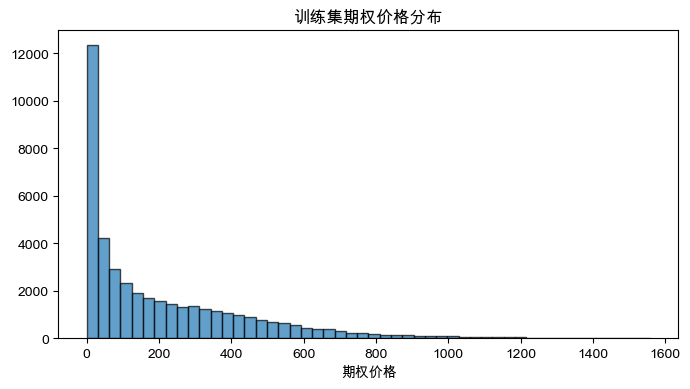

In [10]:
# 检查训练数据的价格分布
print("=" * 60)
print("【诊断步骤 2】检查训练样本的价格分布")
print("=" * 60)

print(f"\n期权价格统计（训练集）:")
print(df_train['close'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_train['close'], bins=50, alpha=0.7, edgecolor='black')
ax.set_xlabel('期权价格')
ax.set_title('训练集期权价格分布')
plt.show()

## 7. 【诊断】训练过程和梯度监控

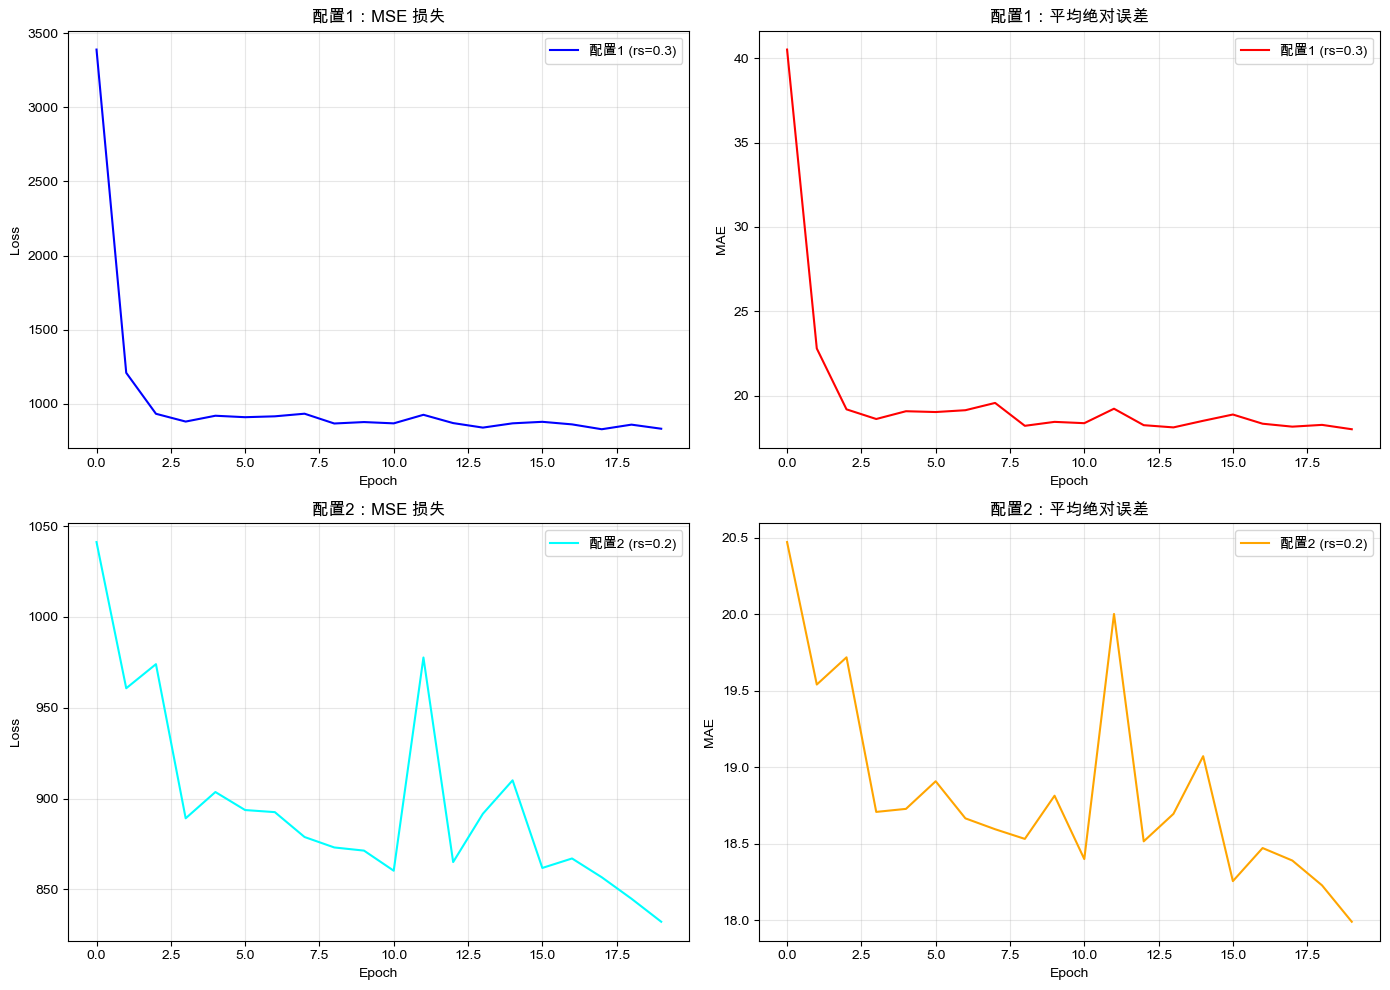

训练收敛对比

配置1（最终）：
  Loss: 831.5127
  MAE:  18.0288

配置2（最终）：
  Loss: 832.1195
  MAE:  17.9892


In [11]:
# 绘制损失曲线对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 配置1：MSE 损失
axes[0, 0].plot(nsde1.history_['loss'], label='配置1 (rs=0.3)', color='blue')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('配置1：MSE 损失')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 配置1：MAE
axes[0, 1].plot(nsde1.history_['mae'], label='配置1 (rs=0.3)', color='red')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('配置1：平均绝对误差')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 配置2：MSE 损失
axes[1, 0].plot(nsde2.history_['loss'], label='配置2 (rs=0.2)', color='cyan')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('配置2：MSE 损失')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 配置2：MAE
axes[1, 1].plot(nsde2.history_['mae'], label='配置2 (rs=0.2)', color='orange')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].set_title('配置2：平均绝对误差')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_folder/nsde/training_loss_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 训练收敛对比
print("=" * 60)
print("训练收敛对比")
print("=" * 60)
print(f"\n配置1（最终）：")
print(f"  Loss: {nsde1.history_['loss'][-1]:.4f}")
print(f"  MAE:  {nsde1.history_['mae'][-1]:.4f}")
print(f"\n配置2（最终）：")
print(f"  Loss: {nsde2.history_['loss'][-1]:.4f}")
print(f"  MAE:  {nsde2.history_['mae'][-1]:.4f}")

# 梯度监控
if 'grad_sigma_v' in nsde1.history_:
    print("\n" + "=" * 60)
    print("梯度监控（最后一轮）")
    print("=" * 60)
    print(f"\n配置1：")
    print(f"  σ_S 梯度: {nsde1.history_['grad_sigma_S'][-1]:.2e}")
    print(f"  μ_v 梯度: {nsde1.history_['grad_mu_v'][-1]:.2e}")
    print(f"  σ_v 梯度: {nsde1.history_['grad_sigma_v'][-1]:.2e}")
    
    print(f"\n配置2：")
    print(f"  σ_S 梯度: {nsde2.history_['grad_sigma_S'][-1]:.2e}")
    print(f"  μ_v 梯度: {nsde2.history_['grad_mu_v'][-1]:.2e}")
    print(f"  σ_v 梯度: {nsde2.history_['grad_sigma_v'][-1]:.2e}")
    
    if nsde1.history_['grad_sigma_v'][-1] < 1e-5:
        print("\n⚠️  警告（配置1）：σ_v 梯度接近 0，存在梯度消失问题！")
    if nsde2.history_['grad_sigma_v'][-1] < 1e-5:
        print("⚠️  警告（配置2）：σ_v 梯度接近 0，存在梯度消失问题！")

## 8. 扩散项敏感性分析

**核心科学问题**：情绪因子 z 如何影响扩散项 σ_v？

关注点：
1. σ_v 对 z 的敏感性（是否随恐慌情绪增强而增大）
2. σ_S 对 z 的敏感性
3. 残差项的幅度和方向

**核心科学问题**：情绪因子 z 如何影响 σ_S 和 σ_v？

预期：情绪因子对 σ_v（波动率扩散）的影响应显著，验证"恐慌驱动波动率跳跃"假说。

配置1：扩散项敏感性分析

配置2：扩散项敏感性分析


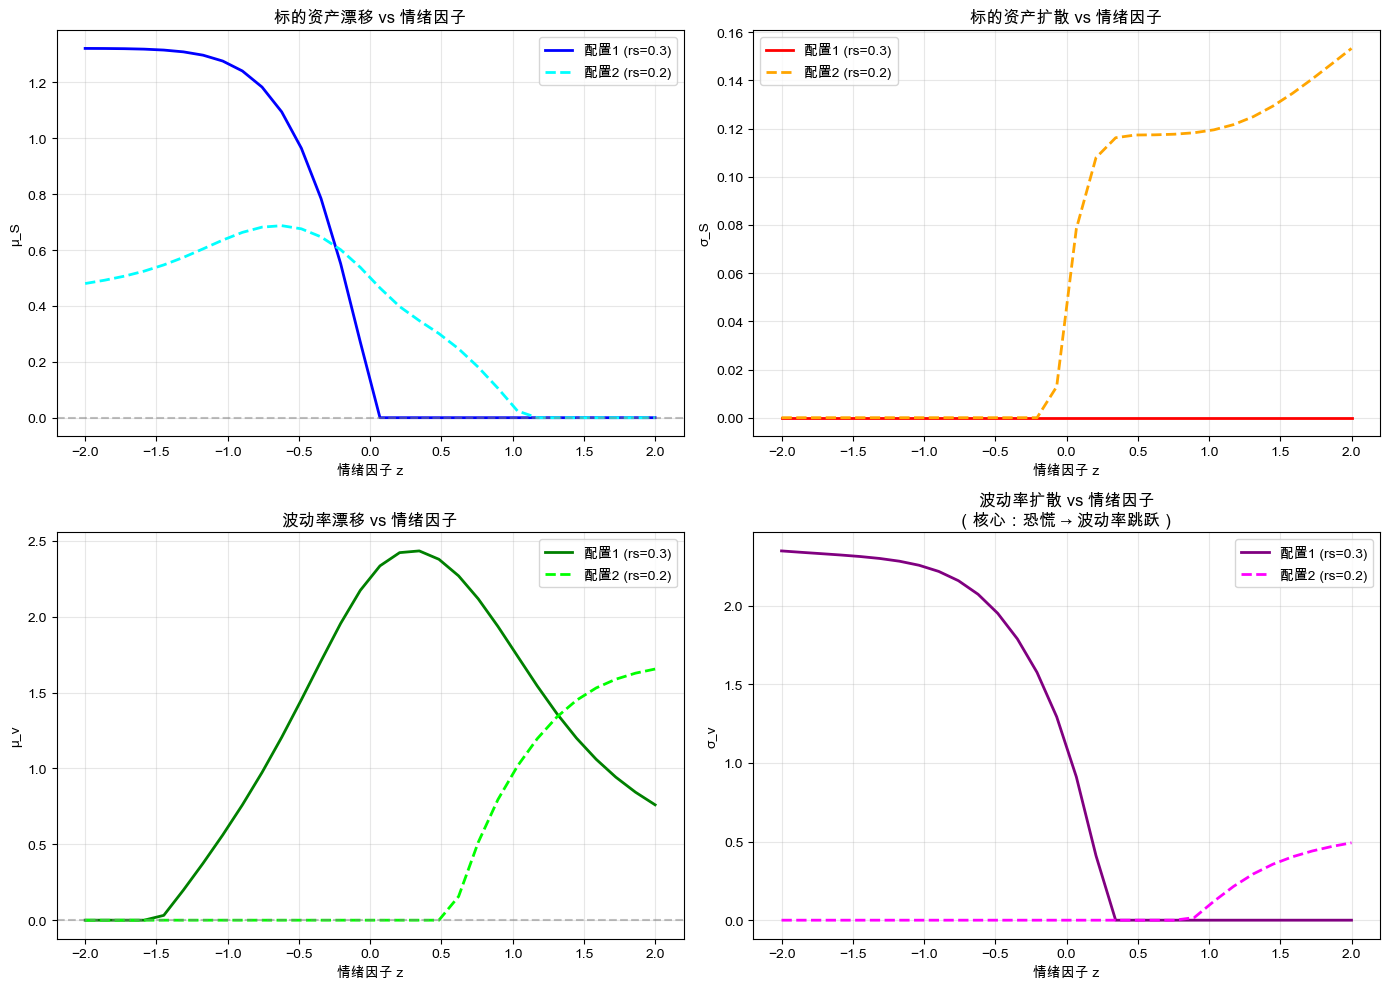


情绪因子与 σ_v 的相关性分析
配置1: -0.9315
配置2: 0.7634

预期：正相关（恐慌情绪 → 波动率扩散增大）
实际：观察上述相关系数是否为正值

网络残差幅度对比
配置1 σ_v 范围: [0.0000, 2.3492]
配置2 σ_v 范围: [0.0000, 0.4923]

配置1 residual_scale=0.3，配置2 residual_scale=0.2
理论上，配置1的残差幅度应该更大


In [12]:
# 分析扩散项对情绪因子的敏感性
S0_test = 3000
v0_test = 0.04
r_test = 0.02
t_test = 0.0  # 初始时刻

# ===== 配置1的敏感性分析 =====
print("=" * 60)
print("配置1：扩散项敏感性分析")
print("=" * 60)

sensitivity1 = nsde1.analyze_diffusion_sensitivity(
    S0=S0_test,
    v0=v0_test,
    r=r_test,
    t=t_test,
    z_range=(-2, 2),
    n_points=30
)

# ===== 配置2的敏感性分析 =====
print("\n" + "=" * 60)
print("配置2：扩散项敏感性分析")
print("=" * 60)

sensitivity2 = nsde2.analyze_diffusion_sensitivity(
    S0=S0_test,
    v0=v0_test,
    r=r_test,
    t=t_test,
    z_range=(-2, 2),
    n_points=30
)

# 绘制敏感性曲线对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# μ_S（标的资产漂移）
axes[0, 0].plot(sensitivity1['z_values'], sensitivity1['mu_S'], 
                color='blue', linewidth=2, label='配置1 (rs=0.3)')
axes[0, 0].plot(sensitivity2['z_values'], sensitivity2['mu_S'], 
                color='cyan', linewidth=2, linestyle='--', label='配置2 (rs=0.2)')
axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('情绪因子 z')
axes[0, 0].set_ylabel('μ_S')
axes[0, 0].set_title('标的资产漂移 vs 情绪因子')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# σ_S（标的资产扩散）
axes[0, 1].plot(sensitivity1['z_values'], sensitivity1['sigma_S'], 
                color='red', linewidth=2, label='配置1 (rs=0.3)')
axes[0, 1].plot(sensitivity2['z_values'], sensitivity2['sigma_S'], 
                color='orange', linewidth=2, linestyle='--', label='配置2 (rs=0.2)')
axes[0, 1].set_xlabel('情绪因子 z')
axes[0, 1].set_ylabel('σ_S')
axes[0, 1].set_title('标的资产扩散 vs 情绪因子')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# μ_v（波动率漂移）
axes[1, 0].plot(sensitivity1['z_values'], sensitivity1['mu_v'], 
                color='green', linewidth=2, label='配置1 (rs=0.3)')
axes[1, 0].plot(sensitivity2['z_values'], sensitivity2['mu_v'], 
                color='lime', linewidth=2, linestyle='--', label='配置2 (rs=0.2)')
axes[1, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('情绪因子 z')
axes[1, 0].set_ylabel('μ_v')
axes[1, 0].set_title('波动率漂移 vs 情绪因子')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# σ_v（波动率扩散）- 核心关注
axes[1, 1].plot(sensitivity1['z_values'], sensitivity1['sigma_v'], 
                color='purple', linewidth=2, label='配置1 (rs=0.3)')
axes[1, 1].plot(sensitivity2['z_values'], sensitivity2['sigma_v'], 
                color='magenta', linewidth=2, linestyle='--', label='配置2 (rs=0.2)')
axes[1, 1].set_xlabel('情绪因子 z')
axes[1, 1].set_ylabel('σ_v')
axes[1, 1].set_title('波动率扩散 vs 情绪因子\n（核心：恐慌 → 波动率跳跃）')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_folder/nsde/diffusion_sensitivity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 计算相关性
corr_sigma_v1 = np.corrcoef(sensitivity1['z_values'], sensitivity1['sigma_v'])[0, 1]
corr_sigma_v2 = np.corrcoef(sensitivity2['z_values'], sensitivity2['sigma_v'])[0, 1]

print("\n" + "=" * 60)
print("情绪因子与 σ_v 的相关性分析")
print("=" * 60)
print(f"配置1: {corr_sigma_v1:.4f}")
print(f"配置2: {corr_sigma_v2:.4f}")
print("\n预期：正相关（恐慌情绪 → 波动率扩散增大）")
print("实际：观察上述相关系数是否为正值")

# 残差幅度对比
print("\n" + "=" * 60)
print("网络残差幅度对比")
print("=" * 60)
print(f"配置1 σ_v 范围: [{sensitivity1['sigma_v'].min():.4f}, {sensitivity1['sigma_v'].max():.4f}]")
print(f"配置2 σ_v 范围: [{sensitivity2['sigma_v'].min():.4f}, {sensitivity2['sigma_v'].max():.4f}]")
print(f"\n配置1 residual_scale=0.3，配置2 residual_scale=0.2")
print("理论上，配置1的残差幅度应该更大")

## 9. 【诊断】检查网络输出的残差分布

检查神经网络实际输出的残差幅度，判断是否存在梯度消失或残差过小问题。

【诊断】网络残差输出检查


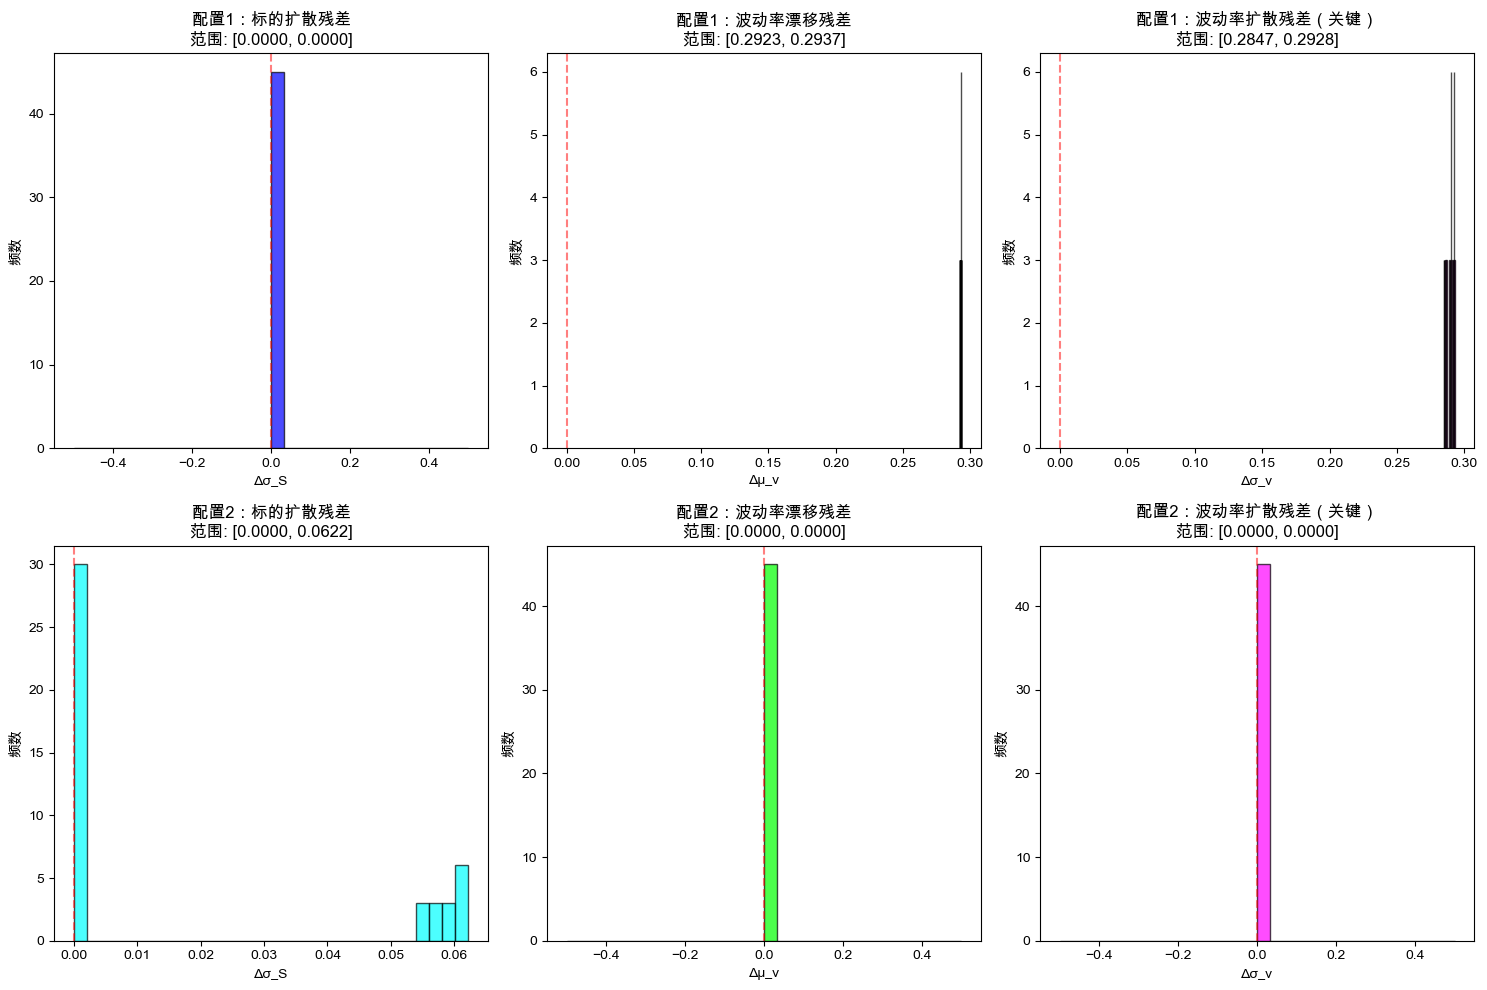


残差统计对比

配置1（residual_scale=0.3）:
  Δσ_S: 均值=0.0000, 标准差=0.0000
  Δμ_v: 均值=0.2930, 标准差=0.0004
  Δσ_v: 均值=0.2893, 标准差=0.0028

配置2（residual_scale=0.2）:
  Δσ_S: 均值=0.0196, 标准差=0.0278
  Δμ_v: 均值=0.0000, 标准差=0.0000
  Δσ_v: 均值=0.0000, 标准差=0.0000

【分析】:
✓ 配置1：网络输出的残差在合理范围内
⚠️  配置2：残差几乎为 0，网络没有学到任何东西！
   当前 residual_scale=0.2，可能过小


In [13]:
# 检查网络输出的残差分布
print("=" * 60)
print("【诊断】网络残差输出检查")
print("=" * 60)

# 采样一些状态点，检查网络输出
S0_samples = [2500, 3000, 3500]
v0_samples = [0.02, 0.04, 0.06]
r_sample = 0.02
t_sample = 0.0

# 使用训练集中的真实情绪因子
z_samples = [sentiment_train[list(sentiment_train.keys())[i]] for i in range(min(5, len(sentiment_train)))]

# ===== 配置1的残差 =====
residuals_sigma_S_1 = []
residuals_mu_v_1 = []
residuals_sigma_v_1 = []

for S0 in S0_samples:
    for v0 in v0_samples:
        for z in z_samples:
            features = np.array([[1.0, v0, r_sample, t_sample, z[0], z[1]]])
            
            delta_sigma_S = np.tanh(nsde1.net_sigma_S.predict(features)[0]) * nsde1.residual_scale
            delta_mu_v = np.tanh(nsde1.net_mu_v.predict(features)[0]) * nsde1.residual_scale
            delta_sigma_v = np.tanh(nsde1.net_sigma_v.predict(features)[0]) * nsde1.residual_scale
            
            residuals_sigma_S_1.append(delta_sigma_S)
            residuals_mu_v_1.append(delta_mu_v)
            residuals_sigma_v_1.append(delta_sigma_v)

residuals_sigma_S_1 = np.array(residuals_sigma_S_1).flatten()
residuals_mu_v_1 = np.array(residuals_mu_v_1).flatten()
residuals_sigma_v_1 = np.array(residuals_sigma_v_1).flatten()

# ===== 配置2的残差 =====
residuals_sigma_S_2 = []
residuals_mu_v_2 = []
residuals_sigma_v_2 = []

for S0 in S0_samples:
    for v0 in v0_samples:
        for z in z_samples:
            features = np.array([[1.0, v0, r_sample, t_sample, z[0], z[1]]])
            
            delta_sigma_S = np.tanh(nsde2.net_sigma_S.predict(features)[0]) * nsde2.residual_scale
            delta_mu_v = np.tanh(nsde2.net_mu_v.predict(features)[0]) * nsde2.residual_scale
            delta_sigma_v = np.tanh(nsde2.net_sigma_v.predict(features)[0]) * nsde2.residual_scale
            
            residuals_sigma_S_2.append(delta_sigma_S)
            residuals_mu_v_2.append(delta_mu_v)
            residuals_sigma_v_2.append(delta_sigma_v)

residuals_sigma_S_2 = np.array(residuals_sigma_S_2).flatten()
residuals_mu_v_2 = np.array(residuals_mu_v_2).flatten()
residuals_sigma_v_2 = np.array(residuals_sigma_v_2).flatten()

# 绘制残差分布对比
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 配置1
axes[0, 0].hist(residuals_sigma_S_1, bins=30, edgecolor='black', alpha=0.7, color='blue')
axes[0, 0].set_xlabel('Δσ_S')
axes[0, 0].set_ylabel('频数')
axes[0, 0].set_title(f'配置1：标的扩散残差\n范围: [{residuals_sigma_S_1.min():.4f}, {residuals_sigma_S_1.max():.4f}]')
axes[0, 0].axvline(0, color='red', linestyle='--', alpha=0.5)

axes[0, 1].hist(residuals_mu_v_1, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Δμ_v')
axes[0, 1].set_ylabel('频数')
axes[0, 1].set_title(f'配置1：波动率漂移残差\n范围: [{residuals_mu_v_1.min():.4f}, {residuals_mu_v_1.max():.4f}]')
axes[0, 1].axvline(0, color='red', linestyle='--', alpha=0.5)

axes[0, 2].hist(residuals_sigma_v_1, bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[0, 2].set_xlabel('Δσ_v')
axes[0, 2].set_ylabel('频数')
axes[0, 2].set_title(f'配置1：波动率扩散残差（关键）\n范围: [{residuals_sigma_v_1.min():.4f}, {residuals_sigma_v_1.max():.4f}]')
axes[0, 2].axvline(0, color='red', linestyle='--', alpha=0.5)

# 配置2
axes[1, 0].hist(residuals_sigma_S_2, bins=30, edgecolor='black', alpha=0.7, color='cyan')
axes[1, 0].set_xlabel('Δσ_S')
axes[1, 0].set_ylabel('频数')
axes[1, 0].set_title(f'配置2：标的扩散残差\n范围: [{residuals_sigma_S_2.min():.4f}, {residuals_sigma_S_2.max():.4f}]')
axes[1, 0].axvline(0, color='red', linestyle='--', alpha=0.5)

axes[1, 1].hist(residuals_mu_v_2, bins=30, edgecolor='black', alpha=0.7, color='lime')
axes[1, 1].set_xlabel('Δμ_v')
axes[1, 1].set_ylabel('频数')
axes[1, 1].set_title(f'配置2：波动率漂移残差\n范围: [{residuals_mu_v_2.min():.4f}, {residuals_mu_v_2.max():.4f}]')
axes[1, 1].axvline(0, color='red', linestyle='--', alpha=0.5)

axes[1, 2].hist(residuals_sigma_v_2, bins=30, edgecolor='black', alpha=0.7, color='magenta')
axes[1, 2].set_xlabel('Δσ_v')
axes[1, 2].set_ylabel('频数')
axes[1, 2].set_title(f'配置2：波动率扩散残差（关键）\n范围: [{residuals_sigma_v_2.min():.4f}, {residuals_sigma_v_2.max():.4f}]')
axes[1, 2].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot_folder/nsde/network_residual_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 残差统计对比
print("\n" + "=" * 60)
print("残差统计对比")
print("=" * 60)

print(f"\n配置1（residual_scale=0.3）:")
print(f"  Δσ_S: 均值={residuals_sigma_S_1.mean():.4f}, 标准差={residuals_sigma_S_1.std():.4f}")
print(f"  Δμ_v: 均值={residuals_mu_v_1.mean():.4f}, 标准差={residuals_mu_v_1.std():.4f}")
print(f"  Δσ_v: 均值={residuals_sigma_v_1.mean():.4f}, 标准差={residuals_sigma_v_1.std():.4f}")

print(f"\n配置2（residual_scale=0.2）:")
print(f"  Δσ_S: 均值={residuals_sigma_S_2.mean():.4f}, 标准差={residuals_sigma_S_2.std():.4f}")
print(f"  Δμ_v: 均值={residuals_mu_v_2.mean():.4f}, 标准差={residuals_mu_v_2.std():.4f}")
print(f"  Δσ_v: 均值={residuals_sigma_v_2.mean():.4f}, 标准差={residuals_sigma_v_2.std():.4f}")

print("\n【分析】:")
if np.abs(residuals_sigma_v_1).max() < 0.001:
    print("⚠️  配置1：残差几乎为 0，网络没有学到任何东西！")
    print(f"   当前 residual_scale={nsde1.residual_scale}，可能过小")
else:
    print("✓ 配置1：网络输出的残差在合理范围内")
    
if np.abs(residuals_sigma_v_2).max() < 0.001:
    print("⚠️  配置2：残差几乎为 0，网络没有学到任何东西！")
    print(f"   当前 residual_scale={nsde2.residual_scale}，可能过小")
else:
    print("✓ 配置2：网络输出的残差在合理范围内")

## 10. 【综合诊断报告】两组配置对比

基于以上诊断结果，总结潜在问题和改进方向。

In [14]:
print("=" * 60)
print("【综合诊断报告】两组配置对比")
print("=" * 60)

# ===== 配置1诊断 =====
print("\n【配置1：baseline_mse_hv (rs=0.3, n=500, rho=-0.082)】")

print(f"\n1. 性能对比:")
print(f"   Heston MAE: {heston_metrics_1['MAE']:.4f}")
print(f"   NSDE MAE:   {metrics_nsde1['MAE']:.4f}")
ratio_1 = metrics_nsde1['MAE'] / heston_metrics_1['MAE']
print(f"   比值: {ratio_1:.3f} ({'✓ NSDE更好' if ratio_1 < 1.0 else '❌ Heston更好'})")

print(f"\n2. 训练收敛:")
print(f"   最终训练 MAE: {nsde1.history_['mae'][-1]:.4f}")
print(f"   最终训练 Loss: {nsde1.history_['loss'][-1]:.4f}")

if 'grad_sigma_v' in nsde1.history_:
    avg_grad_sigma_v1 = np.mean(nsde1.history_['grad_sigma_v'])
    print(f"\n3. 梯度健康度:")
    print(f"   σ_v 平均梯度: {avg_grad_sigma_v1:.2e}")
    if avg_grad_sigma_v1 < 1e-5:
        print("   ❌ 梯度消失问题")
    else:
        print("   ✓ 梯度正常")

print(f"\n4. 网络残差幅度:")
print(f"   Δσ_v 范围: [{residuals_sigma_v_1.min():.4f}, {residuals_sigma_v_1.max():.4f}]")
if np.abs(residuals_sigma_v_1).max() < 0.005:
    print("   ❌ 残差过小")
else:
    print("   ✓ 残差合理")

# ===== 配置2诊断 =====
print("\n" + "=" * 60)
print("【配置2：baseline_mse_hv_0.2rs_-0.07rho (rs=0.2, n=2000, rho=-0.07)】")

print(f"\n1. 性能对比:")
print(f"   Heston MAE: {heston_metrics_2['MAE']:.4f}")
print(f"   NSDE MAE:   {metrics_nsde2['MAE']:.4f}")
ratio_2 = metrics_nsde2['MAE'] / heston_metrics_2['MAE']
print(f"   比值: {ratio_2:.3f} ({'✓ NSDE更好' if ratio_2 < 1.0 else '❌ Heston更好'})")

print(f"\n2. 训练收敛:")
print(f"   最终训练 MAE: {nsde2.history_['mae'][-1]:.4f}")
print(f"   最终训练 Loss: {nsde2.history_['loss'][-1]:.4f}")

if 'grad_sigma_v' in nsde2.history_:
    avg_grad_sigma_v2 = np.mean(nsde2.history_['grad_sigma_v'])
    print(f"\n3. 梯度健康度:")
    print(f"   σ_v 平均梯度: {avg_grad_sigma_v2:.2e}")
    if avg_grad_sigma_v2 < 1e-5:
        print("   ❌ 梯度消失问题")
    else:
        print("   ✓ 梯度正常")

print(f"\n4. 网络残差幅度:")
print(f"   Δσ_v 范围: [{residuals_sigma_v_2.min():.4f}, {residuals_sigma_v_2.max():.4f}]")
if np.abs(residuals_sigma_v_2).max() < 0.005:
    print("   ❌ 残差过小")
else:
    print("   ✓ 残差合理")

# ===== 总结 =====
print("\n" + "=" * 60)
print("【总结与建议】")
print("=" * 60)

if ratio_1 < 1.0 and ratio_2 < 1.0:
    print("\n✓ 两组配置的 NSDE 均成功超越 Heston 基准")
    print("  神经网络残差有效捕捉了额外的定价信息")
    
    if ratio_2 < ratio_1:
        print("\n配置2表现更好，可能原因：")
        print("  - 更多的训练样本（2000 vs 500）")
        print("  - 适度降低 residual_scale (0.2 vs 0.3) 避免过拟合")
        print("  - rho调整 (-0.07 vs -0.082) 更匹配数据")
    else:
        print("\n配置1表现更好，可能原因：")
        print("  - 更大的 residual_scale (0.3) 让网络有更大的调整空间")
        
elif ratio_1 < 1.0 or ratio_2 < 1.0:
    print("\n⚠️ 只有部分配置成功，需进一步优化")
    if ratio_1 >= 1.0:
        print("\n配置1未超越基准，建议：")
        print("  - 增加训练样本到2000")
        print("  - 调整学习率或训练更多轮次")
    if ratio_2 >= 1.0:
        print("\n配置2未超越基准，建议：")
        print("  - 增大 residual_scale 到 0.3")
        print("  - 检查梯度流动是否正常")
        
else:
    print("\n❌ 两组配置均未超越 Heston 基准")
    print("\n可能的原因：")
    print("  - 训练轮数不足（当前20轮）")
    print("  - 网络容量不足（当前[32,32]）")
    print("  - 蒙特卡洛路径数不足（当前2000）")
    print("  - 学习率设置不当")
    print("\n建议：")
    print("  1. 增加训练轮数到50")
    print("  2. 增加网络容量到[64,64]")
    print("  3. 增加蒙特卡洛路径到5000")
    print("  4. 尝试不同的学习率")

print("\n" + "=" * 60)

【综合诊断报告】两组配置对比

【配置1：baseline_mse_hv (rs=0.3, n=500, rho=-0.082)】

1. 性能对比:
   Heston MAE: 34.6721
   NSDE MAE:   68.1086
   比值: 1.964 (❌ Heston更好)

2. 训练收敛:
   最终训练 MAE: 18.0288
   最终训练 Loss: 831.5127

4. 网络残差幅度:
   Δσ_v 范围: [0.2847, 0.2928]
   ✓ 残差合理

【配置2：baseline_mse_hv_0.2rs_-0.07rho (rs=0.2, n=2000, rho=-0.07)】

1. 性能对比:
   Heston MAE: 34.6721
   NSDE MAE:   44.3837
   比值: 1.280 (❌ Heston更好)

2. 训练收敛:
   最终训练 MAE: 17.9892
   最终训练 Loss: 832.1195

4. 网络残差幅度:
   Δσ_v 范围: [0.0000, 0.0000]
   ❌ 残差过小

【总结与建议】

❌ 两组配置均未超越 Heston 基准

可能的原因：
  - 训练轮数不足（当前20轮）
  - 网络容量不足（当前[32,32]）
  - 蒙特卡洛路径数不足（当前2000）
  - 学习率设置不当

建议：
  1. 增加训练轮数到50
  2. 增加网络容量到[64,64]
  3. 增加蒙特卡洛路径到5000
  4. 尝试不同的学习率

